# 📊 Technical Indicators — Visualization Notebook
---
> **Project:** S&P 500 — Algorithmic Trading with ML  
> **Notebook:** `02_indicators_visualization.ipynb`  
> **Authors:** Salah Eddine Goumari · Youssef EL Krouk · Yassine Benmesbah

---

## 📋 Table of Contents

| # | Indicator | Family |
|---|-----------|--------|
| [1](#1-setup--simulated-data) | Setup & Simulated Data | — |
| [2](#2-rsi--relative-strength-index) | RSI — Relative Strength Index | Momentum |
| [3](#3-macd--moving-average-convergence-divergence) | MACD | Momentum |
| [4](#4-roc--rate-of-change) | ROC — Rate of Change | Momentum |
| [5](#5-historical-volatility) | Historical Volatility | Volatility |
| [6](#6-atr--average-true-range) | ATR — Average True Range | Volatility |
| [7](#7-bollinger-bands) | Bollinger Bands | Volatility |
| [8](#8-adx--average-directional-index) | ADX — Average Directional Index | Trend |
| [9](#9-moving-averages--sma--ema) | Moving Averages (SMA & EMA) | Trend |
| [10](#10-all-indicators-dashboard) | All Indicators Dashboard | Summary |

---

---
## 1. Setup & Simulated Data

### 1.1 Imports

All libraries needed for this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Global plot style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'  : '#0F1117',
    'axes.facecolor'    : '#1A1D27',
    'axes.edgecolor'    : '#2D3147',
    'axes.labelcolor'   : '#C8CDD8',
    'axes.titlecolor'   : '#FFFFFF',
    'xtick.color'       : '#8892A4',
    'ytick.color'       : '#8892A4',
    'grid.color'        : '#2D3147',
    'grid.linewidth'    : 0.7,
    'text.color'        : '#C8CDD8',
    'legend.facecolor'  : '#1A1D27',
    'legend.edgecolor'  : '#2D3147',
    'legend.labelcolor' : '#C8CDD8',
    'font.size'         : 9,
})

# ── Color palette ──────────────────────────────────────────────────
C_PRICE  = '#4FC3F7'   # light blue — price
C_GREEN  = '#26C6DA'   # teal green — bullish
C_RED    = '#EF5350'   # red        — bearish
C_GOLD   = '#FFD54F'   # gold       — signal lines
C_PURPLE = '#CE93D8'   # purple     — secondary
C_ORANGE = '#FFA726'   # orange     — ATR / volatility
C_TEAL   = '#80CBC4'   # teal       — long-term
C_GRAY   = '#546E7A'   # gray       — neutral

print("✅ Libraries imported")
print("✅ Plot style configured")

✅ Libraries imported
✅ Plot style configured


### 1.2 Indicator Functions

In [2]:
def compute_RSI(prices, n=14):
    delta    = prices.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/n, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/n, adjust=False).mean()
    RS       = avg_gain / avg_loss
    return 100 - (100 / (1 + RS))

def compute_MACD(prices, fast=12, slow=26, signal=9):
    ema_fast  = prices.ewm(span=fast,   adjust=False).mean()
    ema_slow  = prices.ewm(span=slow,   adjust=False).mean()
    macd      = ema_fast - ema_slow
    sig_line  = macd.ewm(span=signal, adjust=False).mean()
    histogram = macd - sig_line
    return macd, sig_line, histogram

def compute_ROC(prices, n=10):
    return prices.pct_change(periods=n) * 100

def compute_historical_volatility(returns, window=20):
    return returns.rolling(window).std() * np.sqrt(252)

def compute_ATR(high, low, close, n=14):
    tr1 = high - low
    tr2 = (high - close.shift(1)).abs()
    tr3 = (low  - close.shift(1)).abs()
    TR  = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    return TR.ewm(alpha=1/n, adjust=False).mean()

def compute_bollinger_bands(prices, n=20, k=2):
    sma       = prices.rolling(n).mean()
    sigma     = prices.rolling(n).std()
    bb_upper  = sma + k * sigma
    bb_lower  = sma - k * sigma
    pct_b     = (prices - bb_lower) / (bb_upper - bb_lower)
    bandwidth = (bb_upper - bb_lower) / sma
    return bb_upper, bb_lower, pct_b, bandwidth

def compute_ADX(high, low, close, n=14):
    atr      = compute_ATR(high, low, close, n)
    plus_dm  = high.diff().clip(lower=0)
    minus_dm = (-low.diff()).clip(lower=0)
    mask     = plus_dm >= minus_dm
    plus_dm  = plus_dm.where(mask, 0)
    minus_dm = minus_dm.where(~mask, 0)
    plus_di  = 100 * plus_dm.ewm(alpha=1/n, adjust=False).mean() / atr
    minus_di = 100 * minus_dm.ewm(alpha=1/n, adjust=False).mean() / atr
    dx       = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    adx      = dx.ewm(alpha=1/n, adjust=False).mean()
    return adx, plus_di, minus_di

def compute_moving_averages(prices):
    return {
        'SMA_20' : prices.rolling(20).mean(),
        'SMA_50' : prices.rolling(50).mean(),
        'SMA_200': prices.rolling(200).mean(),
        'EMA_20' : prices.ewm(span=20, adjust=False).mean(),
        'EMA_50' : prices.ewm(span=50, adjust=False).mean(),
    }

print("✅ All indicator functions defined")

✅ All indicator functions defined


### 1.3 Simulated Price Data

In [3]:
np.random.seed(42)
n     = 300
dates = pd.date_range(start='2023-01-01', periods=n, freq='B')

close, highs, lows = 150.0, [], []
closes = []

for i in range(n):
    vol   = 0.015 if i < 100 else (0.025 if i < 200 else 0.012)
    trend = 0.0003 if i < 150 else -0.0002
    ret   = trend + vol * np.random.randn()
    close = close * (1 + ret)
    high  = close * (1 + abs(np.random.randn()) * 0.005)
    low   = close * (1 - abs(np.random.randn()) * 0.005)
    closes.append(close)
    highs.append(high)
    lows.append(low)

df = pd.DataFrame({
    'close': closes,
    'high' : highs,
    'low'  : lows
}, index=dates)

prices  = df['close']
high    = df['high']
low     = df['low']
returns = prices.pct_change()

print("✅ Simulated data created")
print(f"   Period      : {dates[0].date()} → {dates[-1].date()}")
print(f"   Observations: {n} trading days")
print(f"   Price range : ${prices.min():.2f} – ${prices.max():.2f}")
print()
df.tail(5).round(3)

✅ Simulated data created
   Period      : 2023-01-02 → 2024-02-23
   Observations: 300 trading days
   Price range : $140.86 – $218.28



,close,high,low
2024-02-19,193.434,193.999,193.087
2024-02-20,194.766,195.846,193.967
2024-02-21,195.913,196.958,194.768
2024-02-22,199.123,199.769,198.957
2024-02-23,199.434,200.637,198.619


### 1.4 Compute All Indicators

In [4]:
# ── Momentum ───────────────────────────────────────────────────────
rsi                           = compute_RSI(prices, n=14)
macd, sig_line, histogram     = compute_MACD(prices)
roc                           = compute_ROC(prices, n=10)

# ── Volatility ─────────────────────────────────────────────────────
hv20                          = compute_historical_volatility(returns, 20)
hv60                          = compute_historical_volatility(returns, 60)
atr                           = compute_ATR(high, low, prices, n=14)
bb_upper, bb_lower, pct_b, bw = compute_bollinger_bands(prices, n=20, k=2)
sma20                         = prices.rolling(20).mean()

# ── Trend ──────────────────────────────────────────────────────────
adx, plus_di, minus_di        = compute_ADX(high, low, prices, n=14)
mas                           = compute_moving_averages(prices)

print("✅ All indicators computed")
print(f"   RSI        — last value : {rsi.iloc[-1]:.2f}")
print(f"   MACD       — last value : {macd.iloc[-1]:.4f}")
print(f"   ROC(10)    — last value : {roc.iloc[-1]:.3f}%")
print(f"   HV(20) ann — last value : {hv20.iloc[-1]:.2%}")
print(f"   ATR(14)    — last value : ${atr.iloc[-1]:.4f}")
print(f"   %B         — last value : {pct_b.iloc[-1]:.4f}")
print(f"   ADX(14)    — last value : {adx.iloc[-1]:.2f}")

✅ All indicators computed
   RSI        — last value : 60.15
   MACD       — last value : -0.1099
   ROC(10)    — last value : 4.328%
   HV(20) ann — last value : 15.61%
   ATR(14)    — last value : $2.7237
   %B         — last value : 0.7664
   ADX(14)    — last value : 16.74


---
## 2. RSI — Relative Strength Index

**Family :** Momentum  
**Formula :** $RSI = 100 - \dfrac{100}{1 + RS}$ where $RS = \dfrac{\overline{G}_n}{\overline{L}_n}$

**Interpretation :**
- `RSI > 70` → **Overbought** — potential sell signal
- `RSI < 30` → **Oversold** — potential buy signal  
- `RSI = 50` → Neutral zone

### 2.1 RSI Values

In [5]:
print("RSI — Last 10 values")
print("=" * 35)
print(rsi.tail(10).round(2).rename('RSI(14)').to_frame().to_string())
print()
print(f"Current RSI      : {rsi.iloc[-1]:.2f}")
print(f"Days overbought  : {(rsi > 70).sum()}  (RSI > 70)")
print(f"Days oversold    : {(rsi < 30).sum()}  (RSI < 30)")
print()
if rsi.iloc[-1] > 70:
    print("⚠️  SIGNAL : OVERBOUGHT — consider reducing long exposure")
elif rsi.iloc[-1] < 30:
    print("✅  SIGNAL : OVERSOLD   — potential buy opportunity")
else:
    print("➡️  SIGNAL : NEUTRAL    — no extreme signal")

RSI — Last 10 values
            RSI(14)
2024-02-12    36.16
2024-02-13    33.21
2024-02-14    31.26
2024-02-15    39.57
2024-02-16    37.44
2024-02-19    48.24
2024-02-20    51.15
2024-02-21    53.58
2024-02-22    59.61
2024-02-23    60.15

Current RSI      : 60.15
Days overbought  : 32  (RSI > 70)
Days oversold    : 1  (RSI < 30)

➡️  SIGNAL : NEUTRAL    — no extreme signal


### 2.2 RSI Chart

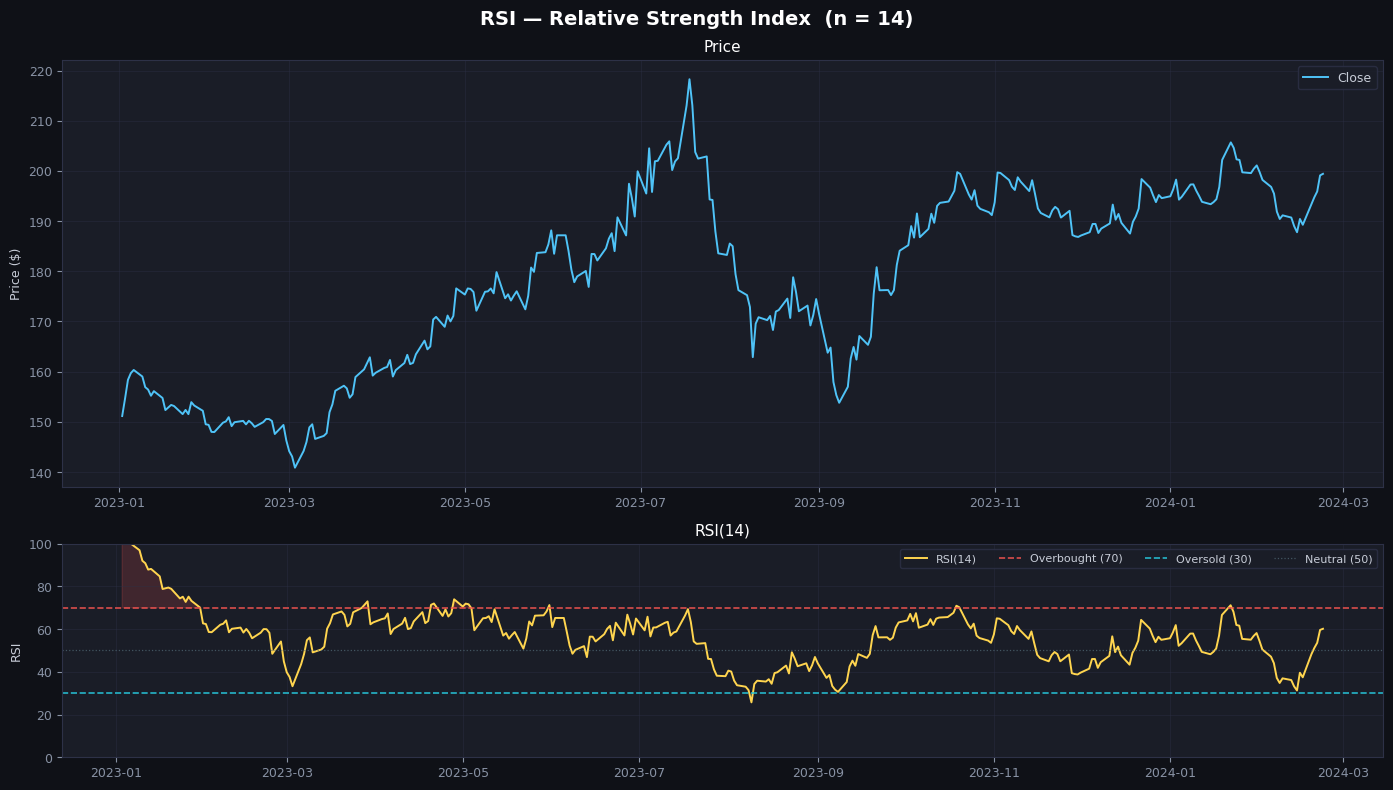

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle('RSI — Relative Strength Index  (n = 14)',
             fontsize=14, fontweight='bold', color='white')

# ── Panel 1 : Price ───────────────────────────────────────────────
ax1.plot(prices.index, prices, color=C_PRICE, linewidth=1.4, label='Close')
ax1.set_ylabel('Price ($)')
ax1.set_title('Price', fontsize=11, color='white')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.4)

# ── Panel 2 : RSI ─────────────────────────────────────────────────
ax2.plot(rsi.index, rsi, color=C_GOLD, linewidth=1.4, label='RSI(14)')
ax2.axhline(70, color=C_RED,   linestyle='--', linewidth=1.2,
            alpha=0.9, label='Overbought (70)')
ax2.axhline(30, color=C_GREEN, linestyle='--', linewidth=1.2,
            alpha=0.9, label='Oversold (30)')
ax2.axhline(50, color=C_GRAY,  linestyle=':',  linewidth=0.9,
            alpha=0.7, label='Neutral (50)')
ax2.fill_between(rsi.index, rsi, 70,
                 where=(rsi >= 70), color=C_RED,   alpha=0.18)
ax2.fill_between(rsi.index, rsi, 30,
                 where=(rsi <= 30), color=C_GREEN, alpha=0.18)
ax2.set_ylim(0, 100)
ax2.set_ylabel('RSI')
ax2.set_title('RSI(14)', fontsize=11, color='white')
ax2.legend(fontsize=8, ncol=4)
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

---
## 3. MACD — Moving Average Convergence Divergence

**Family :** Momentum  
**Formula :**
- $MACD = EMA_{12} - EMA_{26}$  
- $Signal = EMA_9(MACD)$  
- $Histogram = MACD - Signal$

**Interpretation :**
- `MACD > Signal` → **Bullish** momentum
- `MACD < Signal` → **Bearish** momentum
- Histogram crossing zero → **direction change**

### 3.1 MACD Values

In [7]:
macd_df = pd.DataFrame({
    'MACD'     : macd,
    'Signal'   : sig_line,
    'Histogram': histogram
}).dropna()

print("MACD — Last 10 values")
print("=" * 52)
print(macd_df.tail(10).round(4).to_string())
print()
m, s, h = macd.iloc[-1], sig_line.iloc[-1], histogram.iloc[-1]
print(f"Current MACD      : {m:.4f}")
print(f"Current Signal    : {s:.4f}")
print(f"Current Histogram : {h:.4f}")
print()
if m > s:
    print("✅  SIGNAL : BULLISH — MACD above Signal line")
else:
    print("⚠️  SIGNAL : BEARISH — MACD below Signal line")

MACD — Last 10 values
              MACD  Signal  Histogram
2024-02-12 -1.1182  0.2569    -1.3751
2024-02-13 -1.5082 -0.0961    -1.4121
2024-02-14 -1.8932 -0.4555    -1.4377
2024-02-15 -1.9627 -0.7570    -1.2057
2024-02-16 -2.0870 -1.0230    -1.0640
2024-02-19 -1.8290 -1.1842    -0.6448
2024-02-20 -1.4997 -1.2473    -0.2524
2024-02-21 -1.1332 -1.2245     0.0913
2024-02-22 -0.5770 -1.0950     0.5179
2024-02-23 -0.1099 -0.8980     0.7880

Current MACD      : -0.1099
Current Signal    : -0.8980
Current Histogram : 0.7880

✅  SIGNAL : BULLISH — MACD above Signal line


### 3.2 MACD Chart

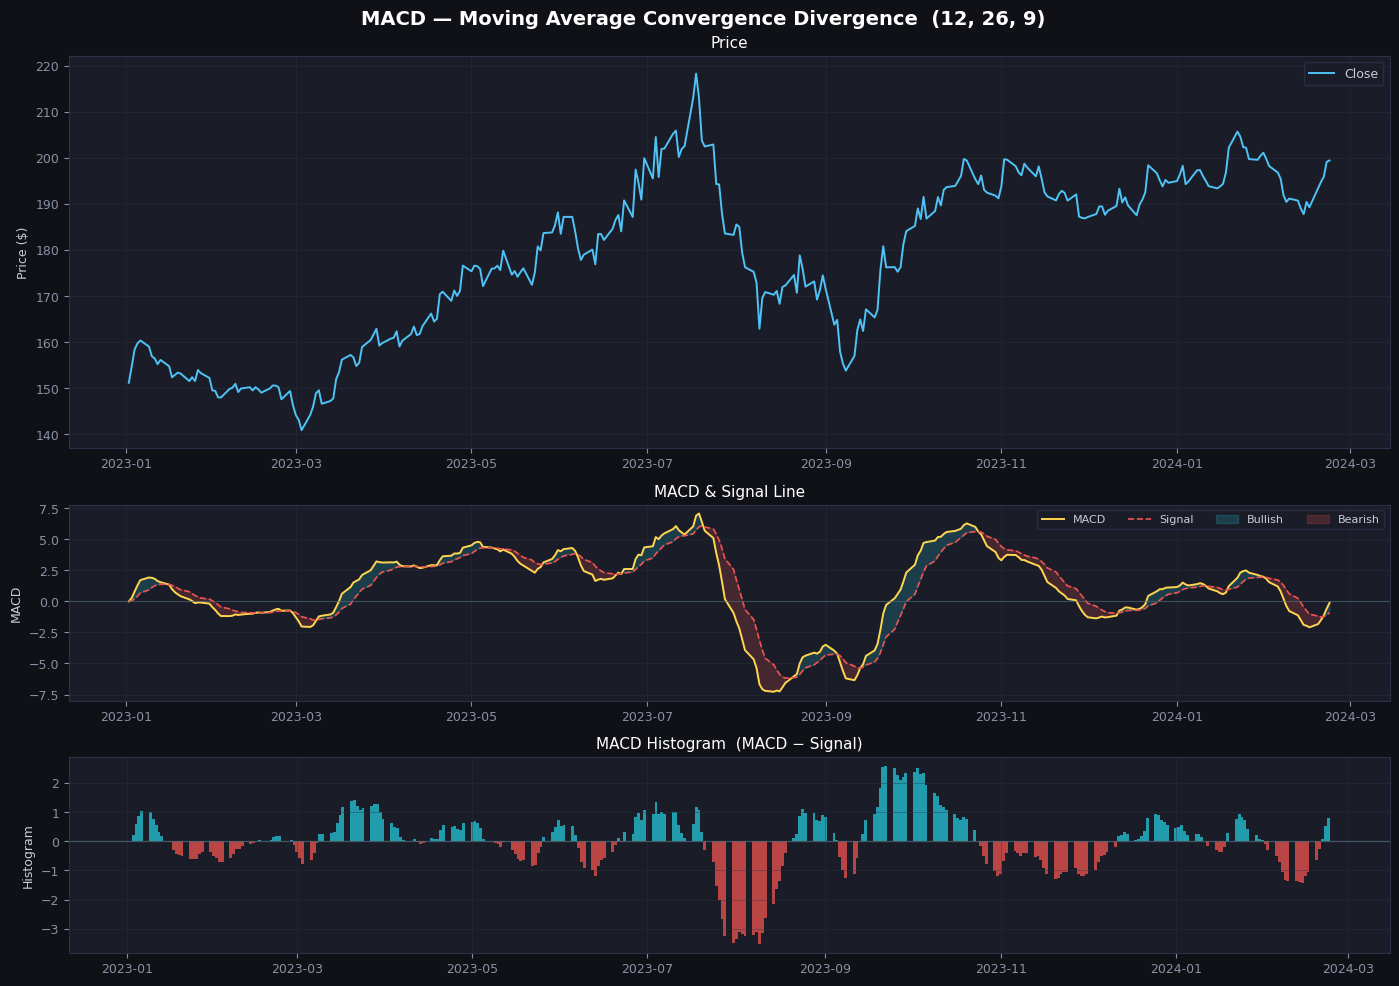

In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10),
                                     gridspec_kw={'height_ratios': [2, 1, 1]})
fig.suptitle('MACD — Moving Average Convergence Divergence  (12, 26, 9)',
             fontsize=14, fontweight='bold', color='white')

# ── Panel 1 : Price ───────────────────────────────────────────────
ax1.plot(prices.index, prices, color=C_PRICE, linewidth=1.4, label='Close')
ax1.set_ylabel('Price ($)')
ax1.set_title('Price', fontsize=11, color='white')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.4)

# ── Panel 2 : MACD & Signal ───────────────────────────────────────
ax2.plot(macd.index,     macd,     color=C_GOLD,  linewidth=1.4, label='MACD')
ax2.plot(sig_line.index, sig_line, color=C_RED,   linewidth=1.2,
         linestyle='--', label='Signal')
ax2.axhline(0, color=C_GRAY, linewidth=0.8, alpha=0.6)
ax2.fill_between(macd.index, macd, sig_line,
                 where=(macd >= sig_line), color=C_GREEN, alpha=0.2,
                 label='Bullish')
ax2.fill_between(macd.index, macd, sig_line,
                 where=(macd < sig_line),  color=C_RED,   alpha=0.2,
                 label='Bearish')
ax2.set_ylabel('MACD')
ax2.set_title('MACD & Signal Line', fontsize=11, color='white')
ax2.legend(fontsize=8, ncol=4)
ax2.grid(True, alpha=0.4)

# ── Panel 3 : Histogram ───────────────────────────────────────────
colors_hist = [C_GREEN if v >= 0 else C_RED for v in histogram.fillna(0)]
ax3.bar(histogram.index, histogram, color=colors_hist, alpha=0.75, width=1)
ax3.axhline(0, color=C_GRAY, linewidth=0.9, alpha=0.7)
ax3.set_ylabel('Histogram')
ax3.set_title('MACD Histogram  (MACD − Signal)', fontsize=11, color='white')
ax3.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

---
## 4. ROC — Rate of Change

**Family :** Momentum  
**Formula :** $ROC_t = \dfrac{P_t - P_{t-n}}{P_{t-n}} \times 100$

**Interpretation :**
- `ROC > 0` → Price is **higher** than n days ago → positive momentum
- `ROC < 0` → Price is **lower** than n days ago → negative momentum
- Crossing zero → **momentum reversal**

### 4.1 ROC Values

In [9]:
print("ROC(10) — Last 10 values")
print("=" * 35)
print(roc.tail(10).round(3).rename('ROC(10) %').to_frame().to_string())
print()
print(f"Current ROC : {roc.iloc[-1]:.3f}%")
print(f"Mean ROC    : {roc.mean():.3f}%")
print(f"Max ROC     : {roc.max():.3f}%")
print(f"Min ROC     : {roc.min():.3f}%")
print()
if roc.iloc[-1] > 0:
    print("✅  SIGNAL : Price HIGHER than 10 days ago — positive momentum")
else:
    print("⚠️  SIGNAL : Price LOWER than 10 days ago — negative momentum")

ROC(10) — Last 10 values
            ROC(10) %
2024-02-12     -4.440
2024-02-13     -5.711
2024-02-14     -6.621
2024-02-15     -4.682
2024-02-16     -4.511
2024-02-19     -1.721
2024-02-20     -0.364
2024-02-21      2.100
2024-02-22      4.563
2024-02-23      4.328

Current ROC : 4.328%
Mean ROC    : 0.859%
Max ROC     : 16.413%
Min ROC     : -16.128%

✅  SIGNAL : Price HIGHER than 10 days ago — positive momentum


### 4.2 ROC Chart

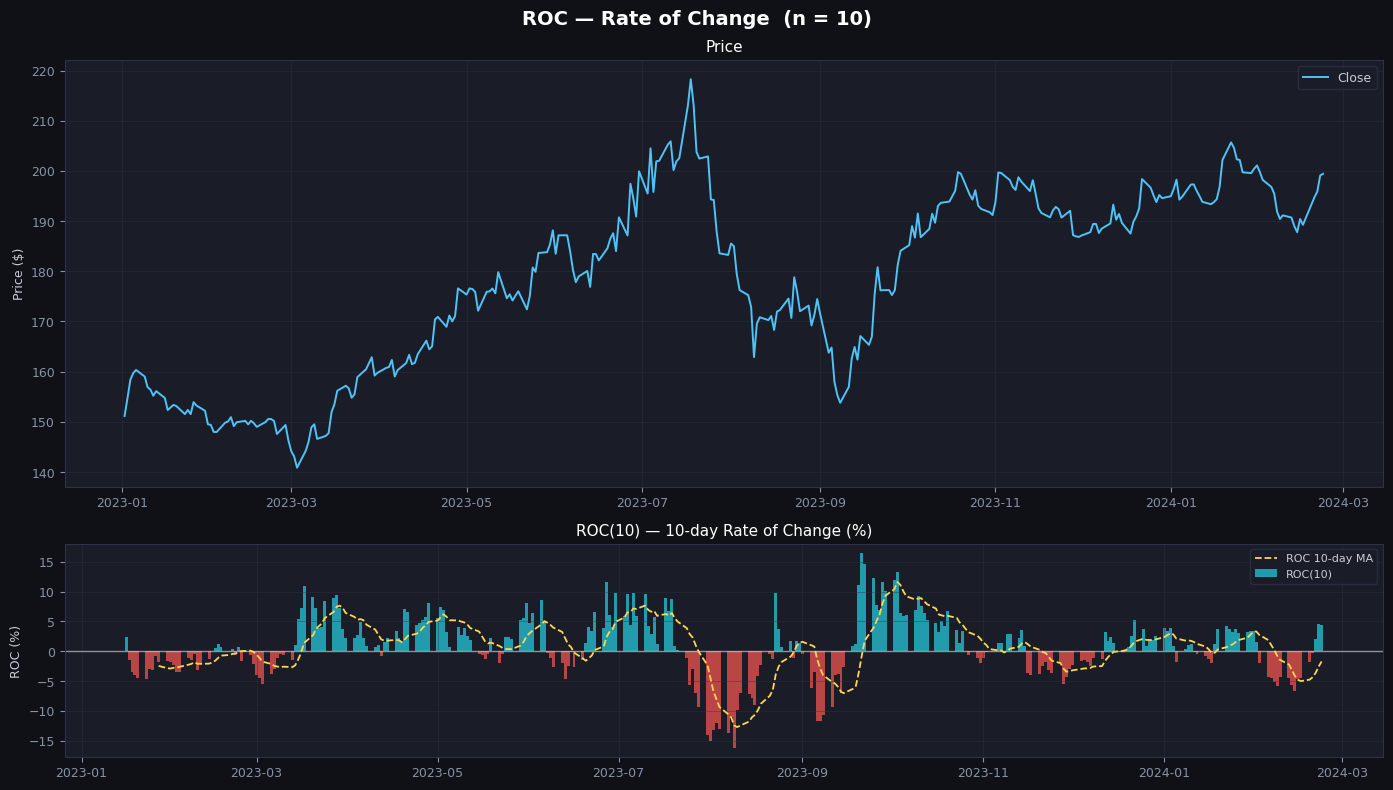

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle('ROC — Rate of Change  (n = 10)',
             fontsize=14, fontweight='bold', color='white')

# ── Panel 1 : Price ───────────────────────────────────────────────
ax1.plot(prices.index, prices, color=C_PRICE, linewidth=1.4, label='Close')
ax1.set_ylabel('Price ($)')
ax1.set_title('Price', fontsize=11, color='white')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.4)

# ── Panel 2 : ROC ─────────────────────────────────────────────────
colors_roc = [C_GREEN if v >= 0 else C_RED for v in roc.fillna(0)]
ax2.bar(roc.index, roc, color=colors_roc, alpha=0.75, width=1, label='ROC(10)')
ax2.axhline(0, color='white', linewidth=1.0, alpha=0.5)
ax2.plot(roc.index, roc.rolling(10).mean(),
         color=C_GOLD, linewidth=1.3, linestyle='--', label='ROC 10-day MA')
ax2.set_ylabel('ROC (%)')
ax2.set_title('ROC(10) — 10-day Rate of Change (%)', fontsize=11, color='white')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

---
## 5. Historical Volatility

**Family :** Volatility  
**Formula :** $\sigma_{ann} = \sqrt{\dfrac{1}{n-1}\sum_{t=1}^{n}(r_t - \bar{r})^2} \times \sqrt{252}$

**Interpretation :**
- High volatility → **large position risk**, reduce size
- Low volatility → **calm market**, normal sizing
- HV20 > HV60 → volatility **increasing** (short > long)

### 5.1 Volatility Values

In [11]:
print("Historical Volatility — Last 10 values")
print("=" * 45)
hv_df = pd.DataFrame({
    'HV(20) ann.' : hv20,
    'HV(60) ann.' : hv60,
}).dropna()
print(hv_df.tail(10).applymap('{:.2%}'.format).to_string())
print()
print(f"Current HV(20)  : {hv20.iloc[-1]:.2%}")
print(f"Current HV(60)  : {hv60.iloc[-1]:.2%}")
print(f"Mean    HV(20)  : {hv20.mean():.2%}")
print(f"Vol ratio(20/60): {(hv20/hv60).iloc[-1]:.3f}")
print()
if hv20.iloc[-1] > hv20.mean():
    print("⚠️  Current vol ABOVE average — reduce position size")
else:
    print("✅  Current vol BELOW average — normal risk environment")

Historical Volatility — Last 10 values
           HV(20) ann. HV(60) ann.
2024-02-12      16.93%      16.51%
2024-02-13      17.14%      16.54%
2024-02-14      17.16%      16.57%
2024-02-15      17.33%      16.83%
2024-02-16      13.57%      16.78%
2024-02-19      14.59%      17.32%
2024-02-20      14.97%      16.54%
2024-02-21      14.87%      16.57%
2024-02-22      16.18%      16.87%
2024-02-23      15.61%      16.87%

Current HV(20)  : 15.61%
Current HV(60)  : 16.87%
Mean    HV(20)  : 25.15%
Vol ratio(20/60): 0.926

✅  Current vol BELOW average — normal risk environment


### 5.2 Historical Volatility Chart

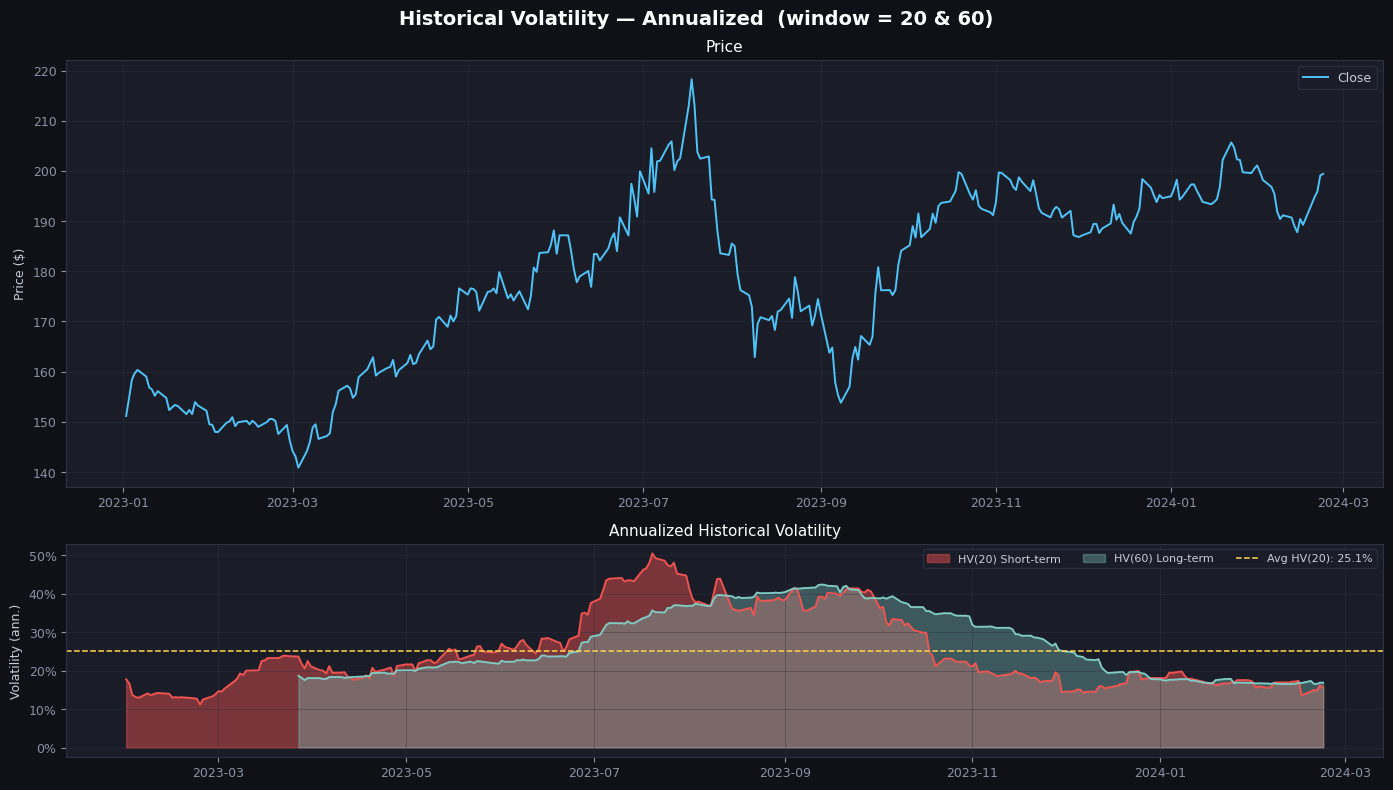

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle('Historical Volatility — Annualized  (window = 20 & 60)',
             fontsize=14, fontweight='bold', color='white')

# ── Panel 1 : Price ───────────────────────────────────────────────
ax1.plot(prices.index, prices, color=C_PRICE, linewidth=1.4, label='Close')
ax1.set_ylabel('Price ($)')
ax1.set_title('Price', fontsize=11, color='white')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.4)

# ── Panel 2 : Volatility ──────────────────────────────────────────
ax2.fill_between(hv20.index, hv20, alpha=0.45, color=C_RED,  label='HV(20) Short-term')
ax2.fill_between(hv60.index, hv60, alpha=0.35, color=C_TEAL, label='HV(60) Long-term')
ax2.plot(hv20.index, hv20, color=C_RED,  linewidth=1.3)
ax2.plot(hv60.index, hv60, color=C_TEAL, linewidth=1.3)
ax2.axhline(hv20.mean(), color=C_GOLD, linestyle='--', linewidth=1.1,
            label=f'Avg HV(20): {hv20.mean():.1%}')
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.set_ylabel('Volatility (ann.)')
ax2.set_title('Annualized Historical Volatility', fontsize=11, color='white')
ax2.legend(fontsize=8, ncol=3)
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

---
## 6. ATR — Average True Range

**Family :** Volatility  
**Formula :**  
$TR_t = \max(H_t - L_t,\ |H_t - C_{t-1}|,\ |L_t - C_{t-1}|)$  
$ATR_t = \text{Wilder smoothing of } TR_t \text{ over } n \text{ periods}$

**Interpretation :**
- ATR expressed in **price units** ($) — directly usable for stops
- High ATR → volatile market → wider stops needed
- Stop suggestion : `P - 2 × ATR`

### 6.1 ATR Values

In [13]:
print("ATR(14) — Last 10 values")
print("=" * 35)
print(atr.tail(10).round(4).rename('ATR(14) $').to_frame().to_string())
print()
cur_atr   = atr.iloc[-1]
cur_price = prices.iloc[-1]
print(f"Current Price   : ${cur_price:.2f}")
print(f"Current ATR(14) : ${cur_atr:.4f}")
print(f"ATR % of Price  : {cur_atr/cur_price*100:.2f}%")
print(f"Stop (1×ATR)    : ${cur_price - cur_atr:.2f}")
print(f"Stop (2×ATR)    : ${cur_price - 2*cur_atr:.2f}")
print(f"Position sizing : Risk $1000 → {1000/cur_atr:.0f} shares at 1 ATR risk")

ATR(14) — Last 10 values
            ATR(14) $
2024-02-12     2.5203
2024-02-13     2.5836
2024-02-14     2.4867
2024-02-15     2.6696
2024-02-16     2.6076
2024-02-19     2.7586
2024-02-20     2.7338
2024-02-21     2.6951
2024-02-22     2.7780
2024-02-23     2.7237

Current Price   : $199.43
Current ATR(14) : $2.7237
ATR % of Price  : 1.37%
Stop (1×ATR)    : $196.71
Stop (2×ATR)    : $193.99
Position sizing : Risk $1000 → 367 shares at 1 ATR risk


### 6.2 ATR Chart

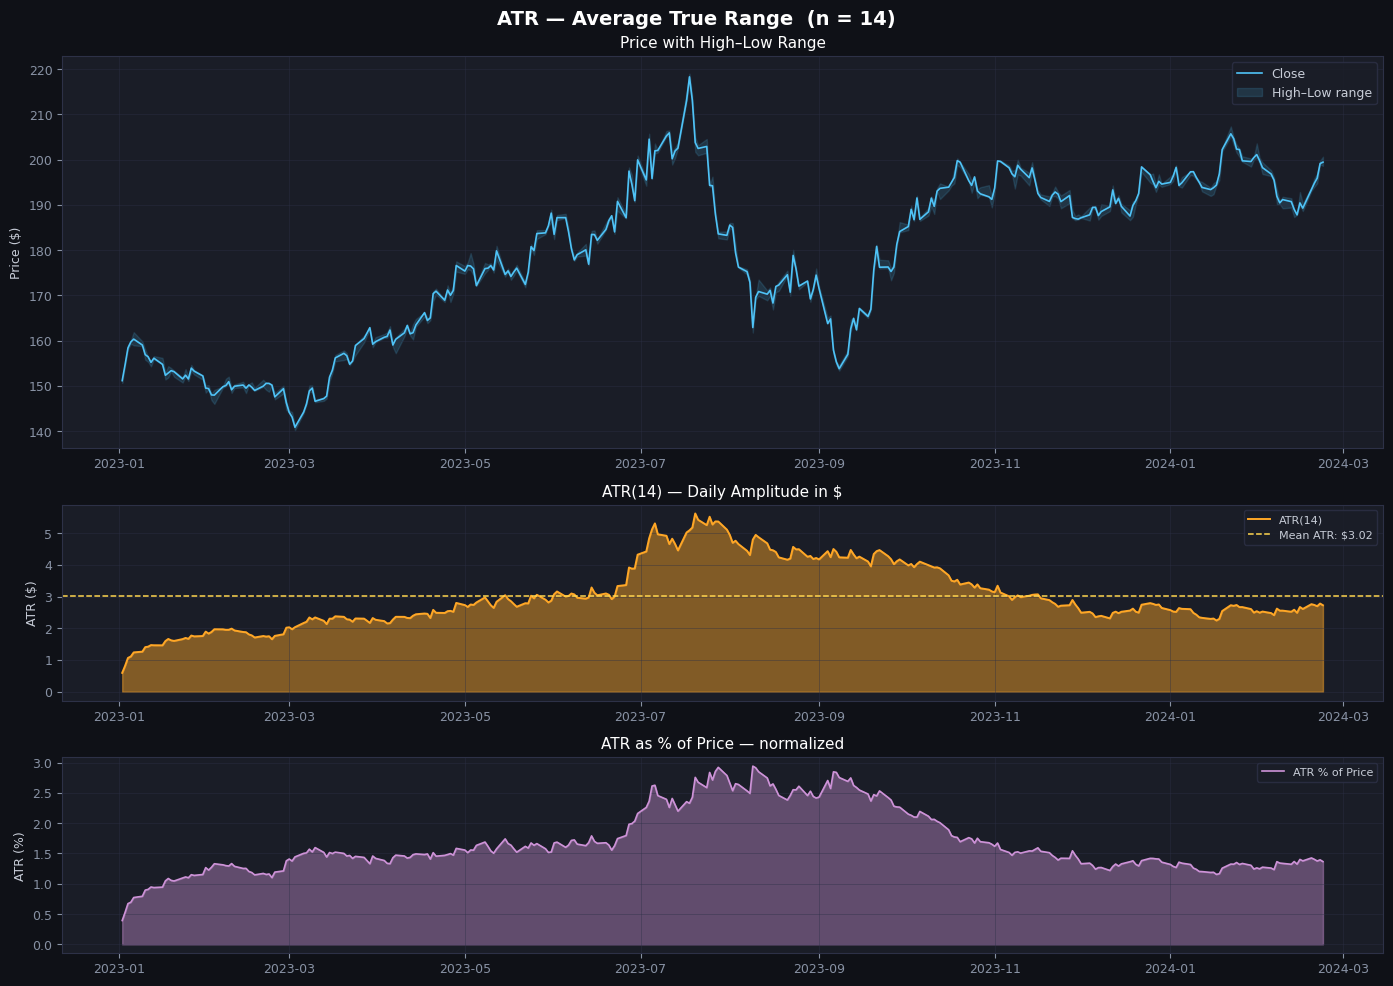

In [14]:
atr_pct = (atr / prices) * 100

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10),
                                     gridspec_kw={'height_ratios': [2, 1, 1]})
fig.suptitle('ATR — Average True Range  (n = 14)',
             fontsize=14, fontweight='bold', color='white')

# ── Panel 1 : Price + High/Low ────────────────────────────────────
ax1.plot(prices.index, prices, color=C_PRICE, linewidth=1.2, label='Close')
ax1.fill_between(prices.index, low, high,
                 alpha=0.15, color=C_PRICE, label='High–Low range')
ax1.set_ylabel('Price ($)')
ax1.set_title('Price with High–Low Range', fontsize=11, color='white')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.4)

# ── Panel 2 : ATR in $ ────────────────────────────────────────────
ax2.fill_between(atr.index, atr, alpha=0.45, color=C_ORANGE)
ax2.plot(atr.index, atr, color=C_ORANGE, linewidth=1.4, label='ATR(14)')
ax2.axhline(atr.mean(), color=C_GOLD, linestyle='--', linewidth=1.1,
            label=f'Mean ATR: ${atr.mean():.2f}')
ax2.set_ylabel('ATR ($)')
ax2.set_title('ATR(14) — Daily Amplitude in $', fontsize=11, color='white')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.4)

# ── Panel 3 : ATR % ───────────────────────────────────────────────
ax3.fill_between(atr_pct.index, atr_pct, alpha=0.4, color=C_PURPLE)
ax3.plot(atr_pct.index, atr_pct, color=C_PURPLE, linewidth=1.2,
         label='ATR % of Price')
ax3.set_ylabel('ATR (%)')
ax3.set_title('ATR as % of Price — normalized', fontsize=11, color='white')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

---
## 7. Bollinger Bands

**Family :** Volatility  
**Formula :**  
$BB_{upper} = SMA_n + k\sigma_n \quad BB_{lower} = SMA_n - k\sigma_n$  
$\%B = \dfrac{P - BB_{lower}}{BB_{upper} - BB_{lower}}$

**Interpretation :**
- `%B > 1` → Price **above** upper band → overbought
- `%B < 0` → Price **below** lower band → oversold
- **Squeeze** (narrow bandwidth) → breakout imminent

### 7.1 Bollinger Bands Values

In [15]:
print("Bollinger Bands — Last 10 values")
print("=" * 70)
bb_df = pd.DataFrame({
    'Close'    : prices,
    'BB_Upper' : bb_upper,
    'BB_Lower' : bb_lower,
    '%B'       : pct_b,
    'Bandwidth': bw,
}).dropna()
print(bb_df.tail(10).round(3).to_string())
print()
pb = pct_b.iloc[-1]
print(f"Current %B        : {pb:.4f}")
print(f"Current Bandwidth : {bw.iloc[-1]:.4f}")
squeeze_thresh = bw.quantile(0.1)
print(f"Squeeze threshold : {squeeze_thresh:.4f} (10th percentile)")
print()
if   pb > 1.0: print("⚠️  Price ABOVE upper band — overbought or strong trend")
elif pb < 0.0: print("✅  Price BELOW lower band — oversold or strong downtrend")
elif pb > 0.8: print("⚠️  Price near upper band — approaching overbought")
elif pb < 0.2: print("✅  Price near lower band — approaching oversold")
else:          print("➡️  Price in middle zone — neutral")
if bw.iloc[-1] < squeeze_thresh:
    print("🔥  SQUEEZE detected — breakout likely imminent!")

Bollinger Bands — Last 10 values
              Close  BB_Upper  BB_Lower     %B  Bandwidth
2024-02-12  190.716   207.226   188.516  0.118      0.095
2024-02-13  189.005   207.648   187.615  0.069      0.101
2024-02-14  187.793   208.166   186.439  0.062      0.110
2024-02-15  190.434   208.273   185.693  0.210      0.115
2024-02-16  189.277   207.845   184.828  0.193      0.117
2024-02-19  193.434   206.409   185.037  0.393      0.109
2024-02-20  194.766   205.063   185.397  0.476      0.101
2024-02-21  195.913   204.171   185.649  0.554      0.095
2024-02-22  199.123   203.600   185.912  0.747      0.091
2024-02-23  199.434   203.550   185.932  0.766      0.090

Current %B        : 0.7664
Current Bandwidth : 0.0905
Squeeze threshold : 0.0526 (10th percentile)

➡️  Price in middle zone — neutral


### 7.2 Bollinger Bands Chart

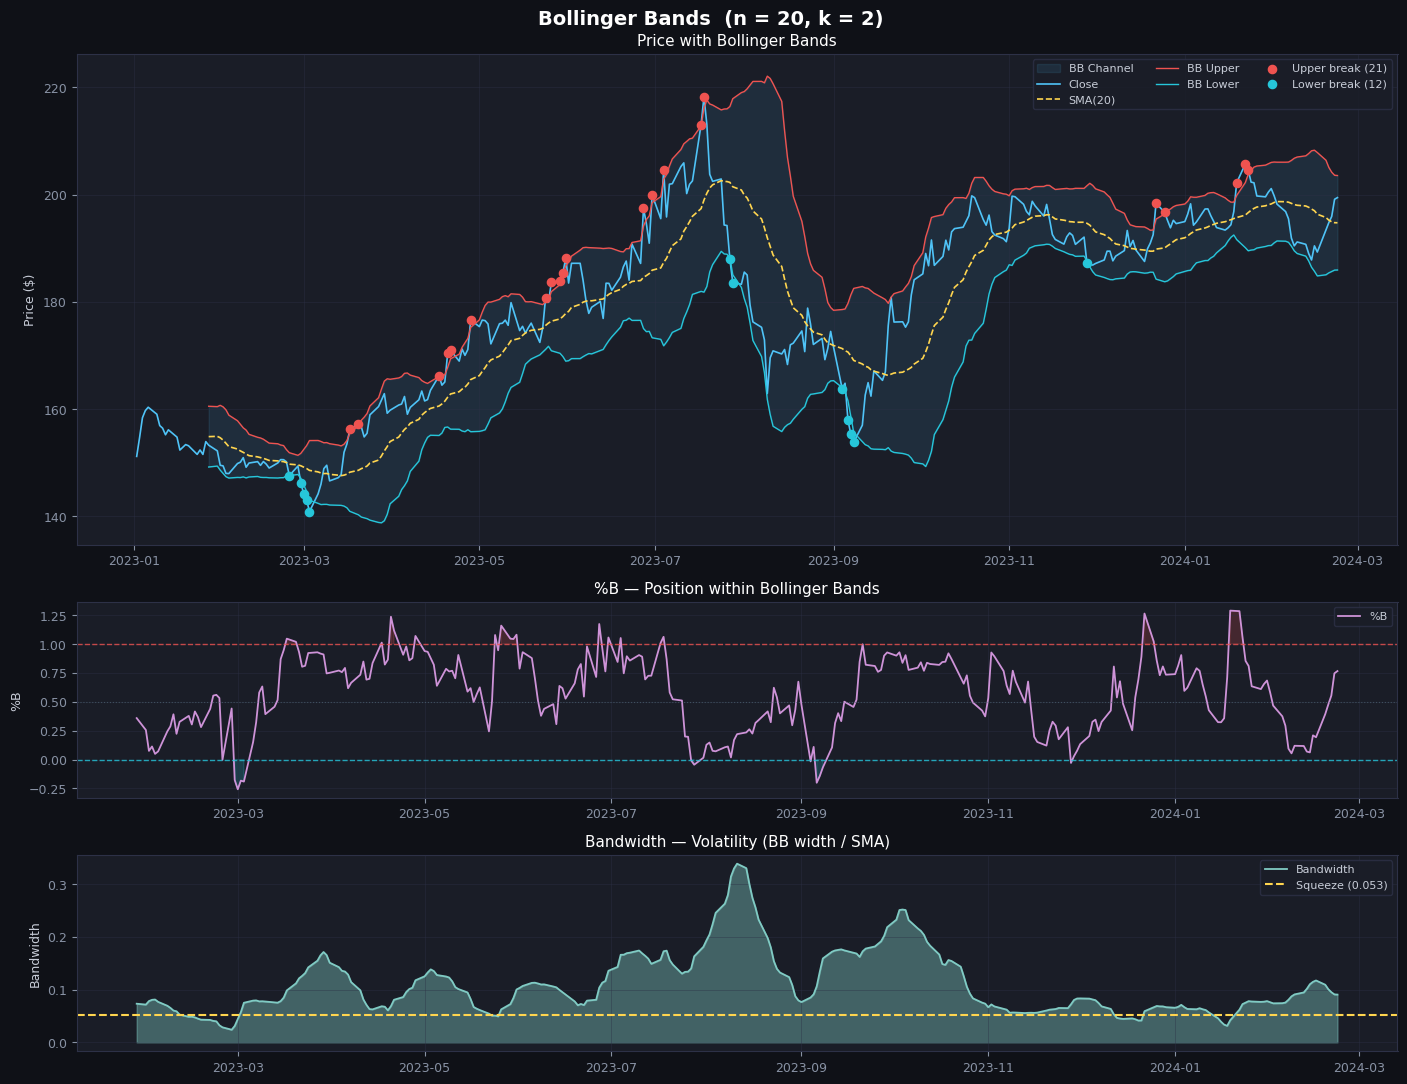

In [16]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 11),
                                     gridspec_kw={'height_ratios': [2.5, 1, 1]})
fig.suptitle('Bollinger Bands  (n = 20, k = 2)',
             fontsize=14, fontweight='bold', color='white')

# ── Panel 1 : Price + Bands ───────────────────────────────────────
ax1.fill_between(bb_upper.index, bb_upper, bb_lower,
                 alpha=0.1, color=C_PRICE, label='BB Channel')
ax1.plot(prices.index,   prices,   color=C_PRICE,  linewidth=1.2, label='Close')
ax1.plot(sma20.index,    sma20,    color=C_GOLD,   linewidth=1.2,
         linestyle='--', label='SMA(20)')
ax1.plot(bb_upper.index, bb_upper, color=C_RED,    linewidth=1.0, label='BB Upper')
ax1.plot(bb_lower.index, bb_lower, color=C_GREEN,  linewidth=1.0, label='BB Lower')
upper_break = prices[prices > bb_upper]
lower_break = prices[prices < bb_lower]
ax1.scatter(upper_break.index, upper_break, color=C_RED,   s=35,
            zorder=5, label=f'Upper break ({len(upper_break)})')
ax1.scatter(lower_break.index, lower_break, color=C_GREEN, s=35,
            zorder=5, label=f'Lower break ({len(lower_break)})')
ax1.set_ylabel('Price ($)')
ax1.set_title('Price with Bollinger Bands', fontsize=11, color='white')
ax1.legend(fontsize=8, ncol=3)
ax1.grid(True, alpha=0.4)

# ── Panel 2 : %B ──────────────────────────────────────────────────
ax2.plot(pct_b.index, pct_b, color=C_PURPLE, linewidth=1.3, label='%B')
ax2.axhline(1.0, color=C_RED,   linestyle='--', linewidth=1.0, alpha=0.8)
ax2.axhline(0.5, color=C_GRAY,  linestyle=':',  linewidth=0.8, alpha=0.6)
ax2.axhline(0.0, color=C_GREEN, linestyle='--', linewidth=1.0, alpha=0.8)
ax2.fill_between(pct_b.index, pct_b, 1,
                 where=(pct_b > 1), color=C_RED,   alpha=0.2)
ax2.fill_between(pct_b.index, pct_b, 0,
                 where=(pct_b < 0), color=C_GREEN, alpha=0.2)
ax2.set_ylabel('%B')
ax2.set_title('%B — Position within Bollinger Bands', fontsize=11, color='white')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.4)

# ── Panel 3 : Bandwidth ───────────────────────────────────────────
ax3.fill_between(bw.index, bw, alpha=0.4, color=C_TEAL)
ax3.plot(bw.index, bw, color=C_TEAL, linewidth=1.3, label='Bandwidth')
ax3.axhline(bw.quantile(0.1), color=C_GOLD, linestyle='--',
            label=f'Squeeze ({bw.quantile(0.1):.3f})')
ax3.set_ylabel('Bandwidth')
ax3.set_title('Bandwidth — Volatility (BB width / SMA)', fontsize=11, color='white')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

---
## 8. ADX — Average Directional Index

**Family :** Trend  
**Formula :**  
$+DI_n = 100 \cdot \dfrac{EMA_n(+DM)}{ATR_n} \quad -DI_n = 100 \cdot \dfrac{EMA_n(-DM)}{ATR_n}$  
$ADX = EMA_n(DX_t)$

**Interpretation :**
- `ADX < 20` → **No trend** — use mean-reversion strategy
- `ADX 20–40` → **Moderate trend** — trend-following applicable
- `ADX > 40` → **Strong trend** — follow aggressively
- `+DI > -DI` → **Bullish** direction

### 8.1 ADX Values

In [18]:
print("ADX — Last 10 values")
print("=" * 55)
direction = ['↑ Bull' if p > m else '↓ Bear'
             for p, m in zip(plus_di, minus_di)]
adx_df = pd.DataFrame({
    'ADX'      : adx,
    '+DI'      : plus_di,
    '-DI'      : minus_di,
    'Direction': direction,
}).dropna()
print(adx_df.tail(10).assign(
    ADX=adx_df['ADX'].round(2),
    **{'+DI': adx_df['+DI'].round(2)},
    **{'-DI': adx_df['-DI'].round(2)}
).to_string())
print()
cur_adx = adx.iloc[-1]
print(f"Current ADX : {cur_adx:.2f}")
if   cur_adx < 20:  print("➡️  No trend — use mean-reversion strategy")
elif cur_adx < 25:  print("⚠️  Weak trend emerging — wait for confirmation")
elif cur_adx < 40:  print("✅  Moderate trend — trend-following applicable")
else:               print("🚀  STRONG trend — follow aggressively")

ADX — Last 10 values
              ADX    +DI    -DI Direction
2024-02-12  14.76  25.89  36.24    ↓ Bear
2024-02-13  15.45  23.45  38.61    ↓ Bear
2024-02-14  16.09  22.62  37.25    ↓ Bear
2024-02-15  14.97  32.51  32.22    ↑ Bull
2024-02-16  14.26  30.90  34.18    ↓ Bear
2024-02-19  13.97  36.79  30.00    ↑ Bull
2024-02-20  14.16  39.30  28.11    ↑ Bull
2024-02-21  14.60  39.97  26.48    ↑ Bull
2024-02-22  15.62  43.23  23.85    ↑ Bull
2024-02-23  16.74  43.22  22.59    ↑ Bull

Current ADX : 16.74
➡️  No trend — use mean-reversion strategy


### 8.2 ADX Chart

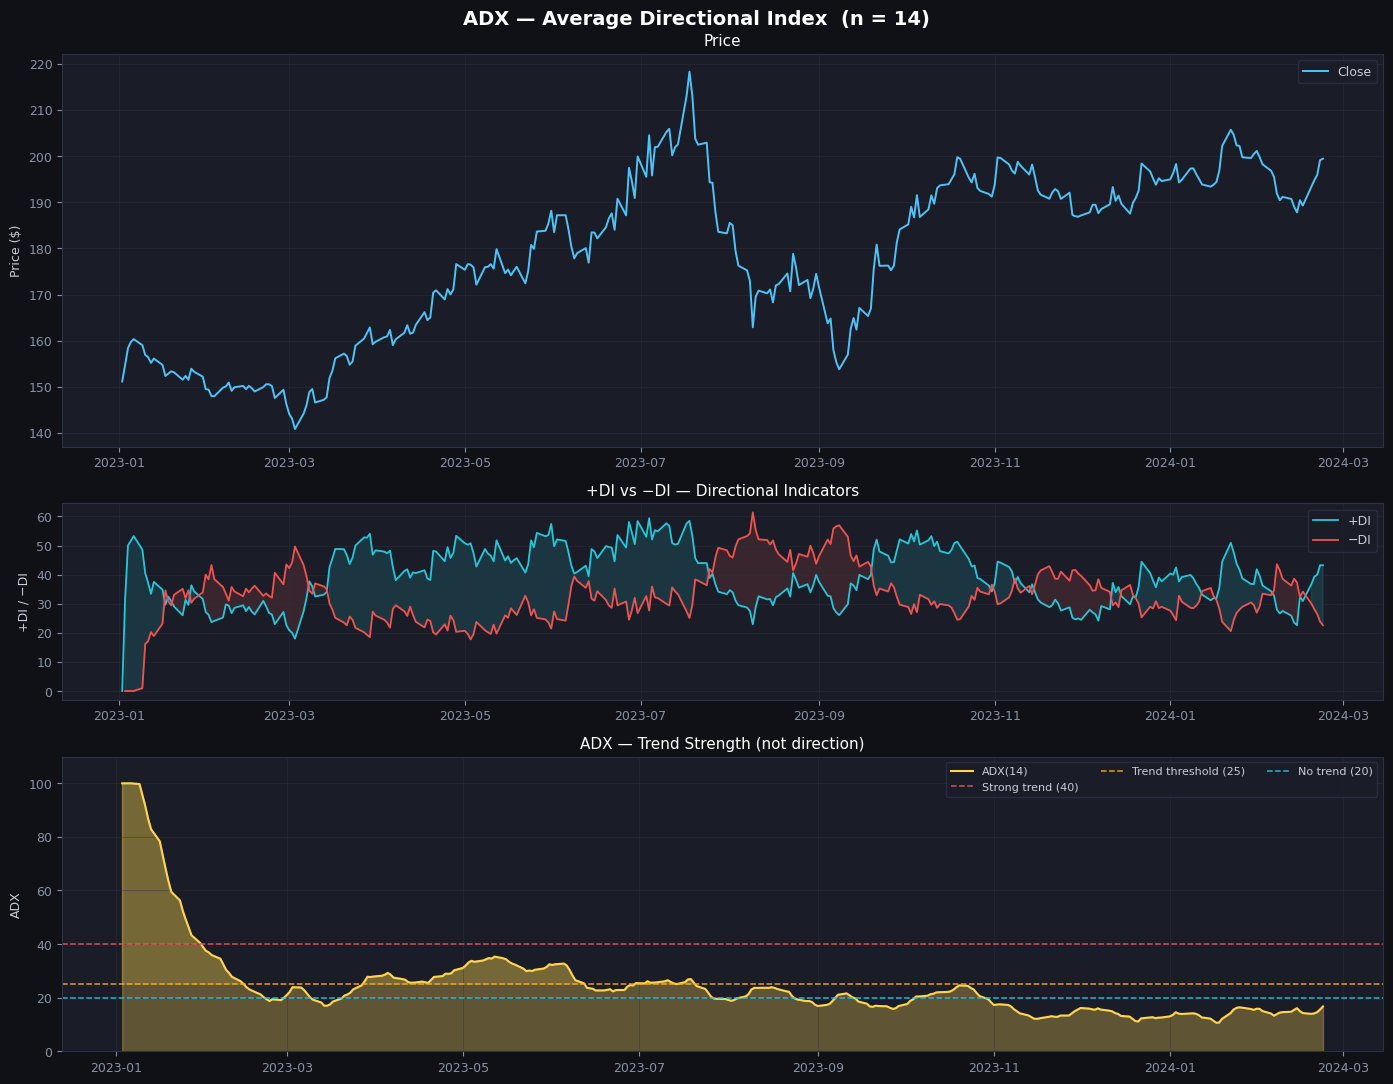

In [19]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 11),
                                     gridspec_kw={'height_ratios': [2, 1, 1.5]})
fig.suptitle('ADX — Average Directional Index  (n = 14)',
             fontsize=14, fontweight='bold', color='white')

# ── Panel 1 : Price ───────────────────────────────────────────────
ax1.plot(prices.index, prices, color=C_PRICE, linewidth=1.4, label='Close')
ax1.set_ylabel('Price ($)')
ax1.set_title('Price', fontsize=11, color='white')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.4)

# ── Panel 2 : +DI vs -DI ─────────────────────────────────────────
ax2.plot(plus_di.index,  plus_di,  color=C_GREEN, linewidth=1.3, label='+DI')
ax2.plot(minus_di.index, minus_di, color=C_RED,   linewidth=1.3, label='−DI')
ax2.fill_between(plus_di.index, plus_di, minus_di,
                 where=(plus_di >= minus_di), color=C_GREEN, alpha=0.15)
ax2.fill_between(plus_di.index, plus_di, minus_di,
                 where=(plus_di <  minus_di), color=C_RED,   alpha=0.15)
ax2.set_ylabel('+DI / −DI')
ax2.set_title('+DI vs −DI — Directional Indicators', fontsize=11, color='white')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4)

# ── Panel 3 : ADX ────────────────────────────────────────────────
ax3.fill_between(adx.index, adx, alpha=0.3, color=C_GOLD)
ax3.plot(adx.index, adx, color=C_GOLD, linewidth=1.5, label='ADX(14)')
ax3.axhline(40, color=C_RED,    linestyle='--', linewidth=1.1,
            alpha=0.9, label='Strong trend (40)')
ax3.axhline(25, color=C_ORANGE, linestyle='--', linewidth=1.1,
            alpha=0.9, label='Trend threshold (25)')
ax3.axhline(20, color=C_GREEN,  linestyle='--', linewidth=1.1,
            alpha=0.9, label='No trend (20)')
ax3.fill_between(adx.index, adx, 25,
                 where=(adx >= 25), color=C_GOLD, alpha=0.15)
ax3.set_ylim(0, max(adx.max() * 1.1, 50))
ax3.set_ylabel('ADX')
ax3.set_title('ADX — Trend Strength (not direction)', fontsize=11, color='white')
ax3.legend(fontsize=8, ncol=3)
ax3.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

---
## 9. Moving Averages — SMA & EMA

**Family :** Trend  
**Formula :**  
$SMA_n = \dfrac{1}{n}\sum_{i=0}^{n-1}P_{t-i} \quad EMA_t = \alpha P_t + (1-\alpha)EMA_{t-1}$

**Interpretation :**
- Price **above** all MAs → full bullish alignment
- **Golden Cross** : SMA50 crosses above SMA200 → long-term bullish
- **Death Cross** : SMA50 crosses below SMA200 → long-term bearish

### 9.1 Moving Averages Values

In [20]:
print("Moving Averages — Last 5 values")
print("=" * 65)
ma_df = pd.DataFrame({'Close': prices, **mas}).dropna()
print(ma_df.tail(5).round(2).to_string())
print()
cur = prices.iloc[-1]
print(f"Current Price : ${cur:.2f}")
for name, ma in mas.items():
    v = ma.iloc[-1]
    if pd.notna(v):
        diff = (cur - v) / v * 100
        sig  = '↑ above' if cur > v else '↓ below'
        print(f"  {name:<8}: ${v:.2f}  ({diff:+.2f}% {sig})")

# Golden / Death Cross detection
sma50  = mas['SMA_50']
sma200 = mas['SMA_200']
cross  = np.sign(sma50 - sma200)
gc     = cross[(cross == 1)  & (cross.shift(1) == -1)]
dc     = cross[(cross == -1) & (cross.shift(1) ==  1)]
print()
print(f"Golden Cross occurrences : {len(gc)}")
print(f"Death Cross occurrences  : {len(dc)}")

Moving Averages — Last 5 values
             Close  SMA_20  SMA_50  SMA_200  EMA_20  EMA_50
2024-02-19  193.43  195.72  195.17   187.80  193.67  194.25
2024-02-20  194.77  195.23  195.20   187.90  193.77  194.27
2024-02-21  195.91  194.91  195.31   188.01  193.98  194.34
2024-02-22  199.12  194.76  195.46   188.13  194.47  194.53
2024-02-23  199.43  194.74  195.66   188.25  194.94  194.72

Current Price : $199.43
  SMA_20  : $194.74  (+2.41% ↑ above)
  SMA_50  : $195.66  (+1.93% ↑ above)
  SMA_200 : $188.25  (+5.94% ↑ above)
  EMA_20  : $194.94  (+2.31% ↑ above)
  EMA_50  : $194.72  (+2.42% ↑ above)

Golden Cross occurrences : 0
Death Cross occurrences  : 0


### 9.2 Moving Averages Chart

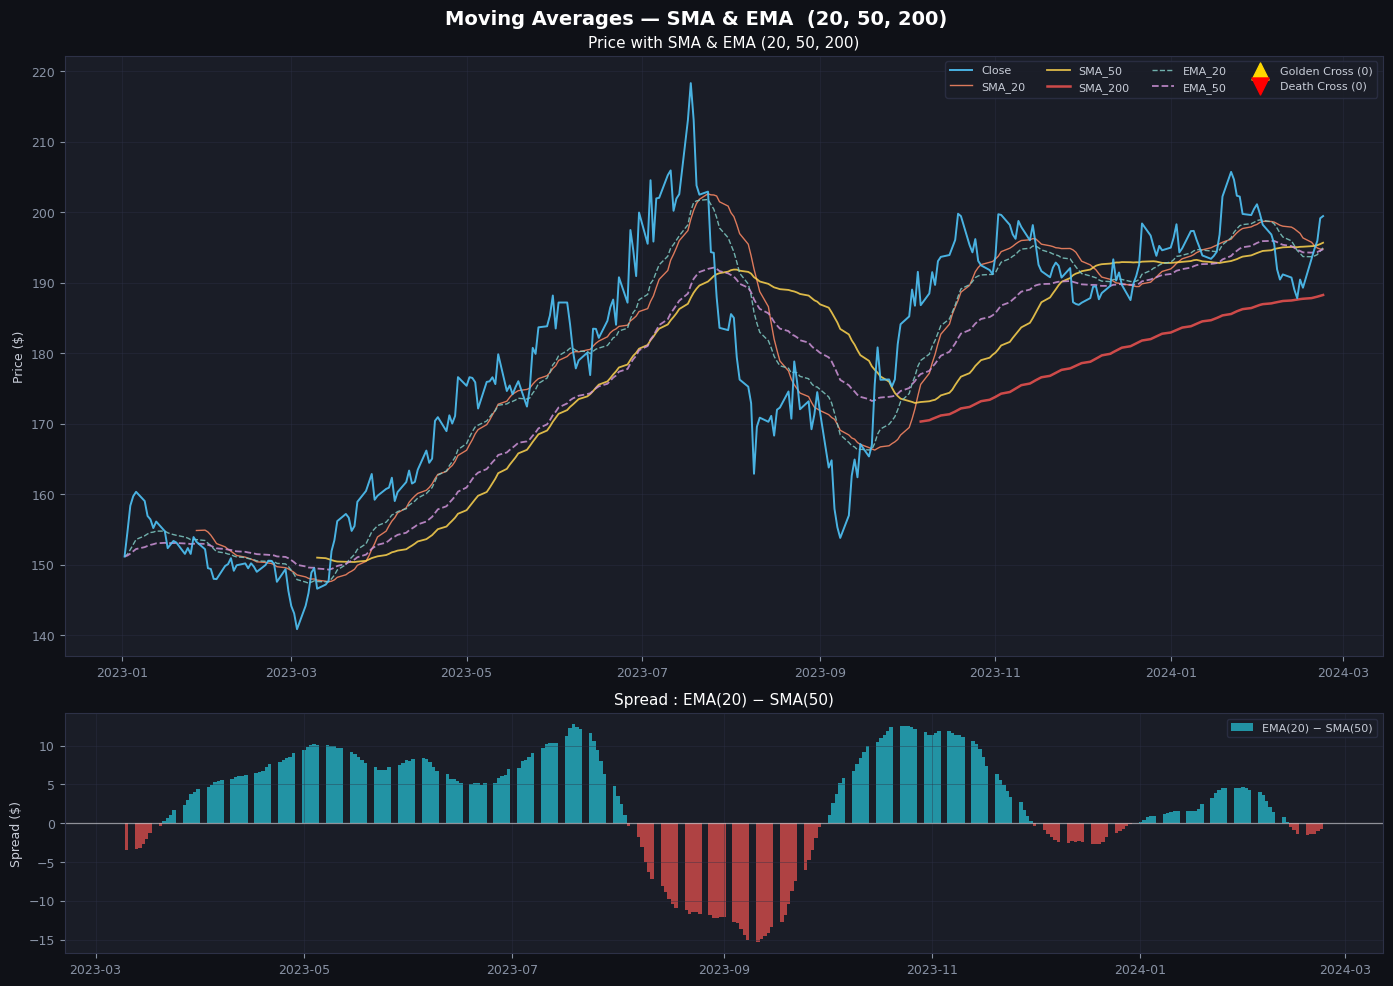

In [21]:
sma50  = mas['SMA_50']
sma200 = mas['SMA_200']
cross  = np.sign(sma50 - sma200)
gc     = cross[(cross == 1)  & (cross.shift(1) == -1)]
dc     = cross[(cross == -1) & (cross.shift(1) ==  1)]
spread = mas['EMA_20'] - mas['SMA_50']

ma_colors = {'SMA_20':'#FF8A65','SMA_50':'#FFD54F',
             'SMA_200':'#EF5350','EMA_20':'#80CBC4','EMA_50':'#CE93D8'}
ma_styles = {'SMA_20':'-','SMA_50':'-','SMA_200':'-',
             'EMA_20':'--','EMA_50':'--'}
ma_widths = {'SMA_20':1.0,'SMA_50':1.3,'SMA_200':1.8,
             'EMA_20':1.0,'EMA_50':1.3}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10),
                                gridspec_kw={'height_ratios': [2.5, 1]})
fig.suptitle('Moving Averages — SMA & EMA  (20, 50, 200)',
             fontsize=14, fontweight='bold', color='white')

# ── Panel 1 : Price + MAs ────────────────────────────────────────
ax1.plot(prices.index, prices, color=C_PRICE, linewidth=1.4,
         alpha=0.9, label='Close', zorder=5)
for name, ma in mas.items():
    ax1.plot(ma.index, ma, color=ma_colors[name],
             linewidth=ma_widths[name], linestyle=ma_styles[name],
             label=name, alpha=0.85)
ax1.scatter(gc.index, prices.loc[gc.index], marker='^', s=150,
            color='gold', zorder=10, label=f'Golden Cross ({len(gc)})')
ax1.scatter(dc.index, prices.loc[dc.index], marker='v', s=150,
            color='red',  zorder=10, label=f'Death Cross ({len(dc)})')
ax1.set_ylabel('Price ($)')
ax1.set_title('Price with SMA & EMA (20, 50, 200)', fontsize=11, color='white')
ax1.legend(fontsize=8, ncol=4)
ax1.grid(True, alpha=0.4)

# ── Panel 2 : Spread ─────────────────────────────────────────────
colors_spread = [C_GREEN if v >= 0 else C_RED for v in spread.fillna(0)]
ax2.bar(spread.index, spread, color=colors_spread,
        alpha=0.7, width=1, label='EMA(20) − SMA(50)')
ax2.axhline(0, color='white', linewidth=0.9, alpha=0.5)
ax2.set_ylabel('Spread ($)')
ax2.set_title('Spread : EMA(20) − SMA(50)', fontsize=11, color='white')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

---
## 10. All Indicators Dashboard

A single view combining all indicators for a complete market reading.

### 10.1 Full Dashboard

In [27]:
import os
os.makedirs("outputs", exist_ok=True)

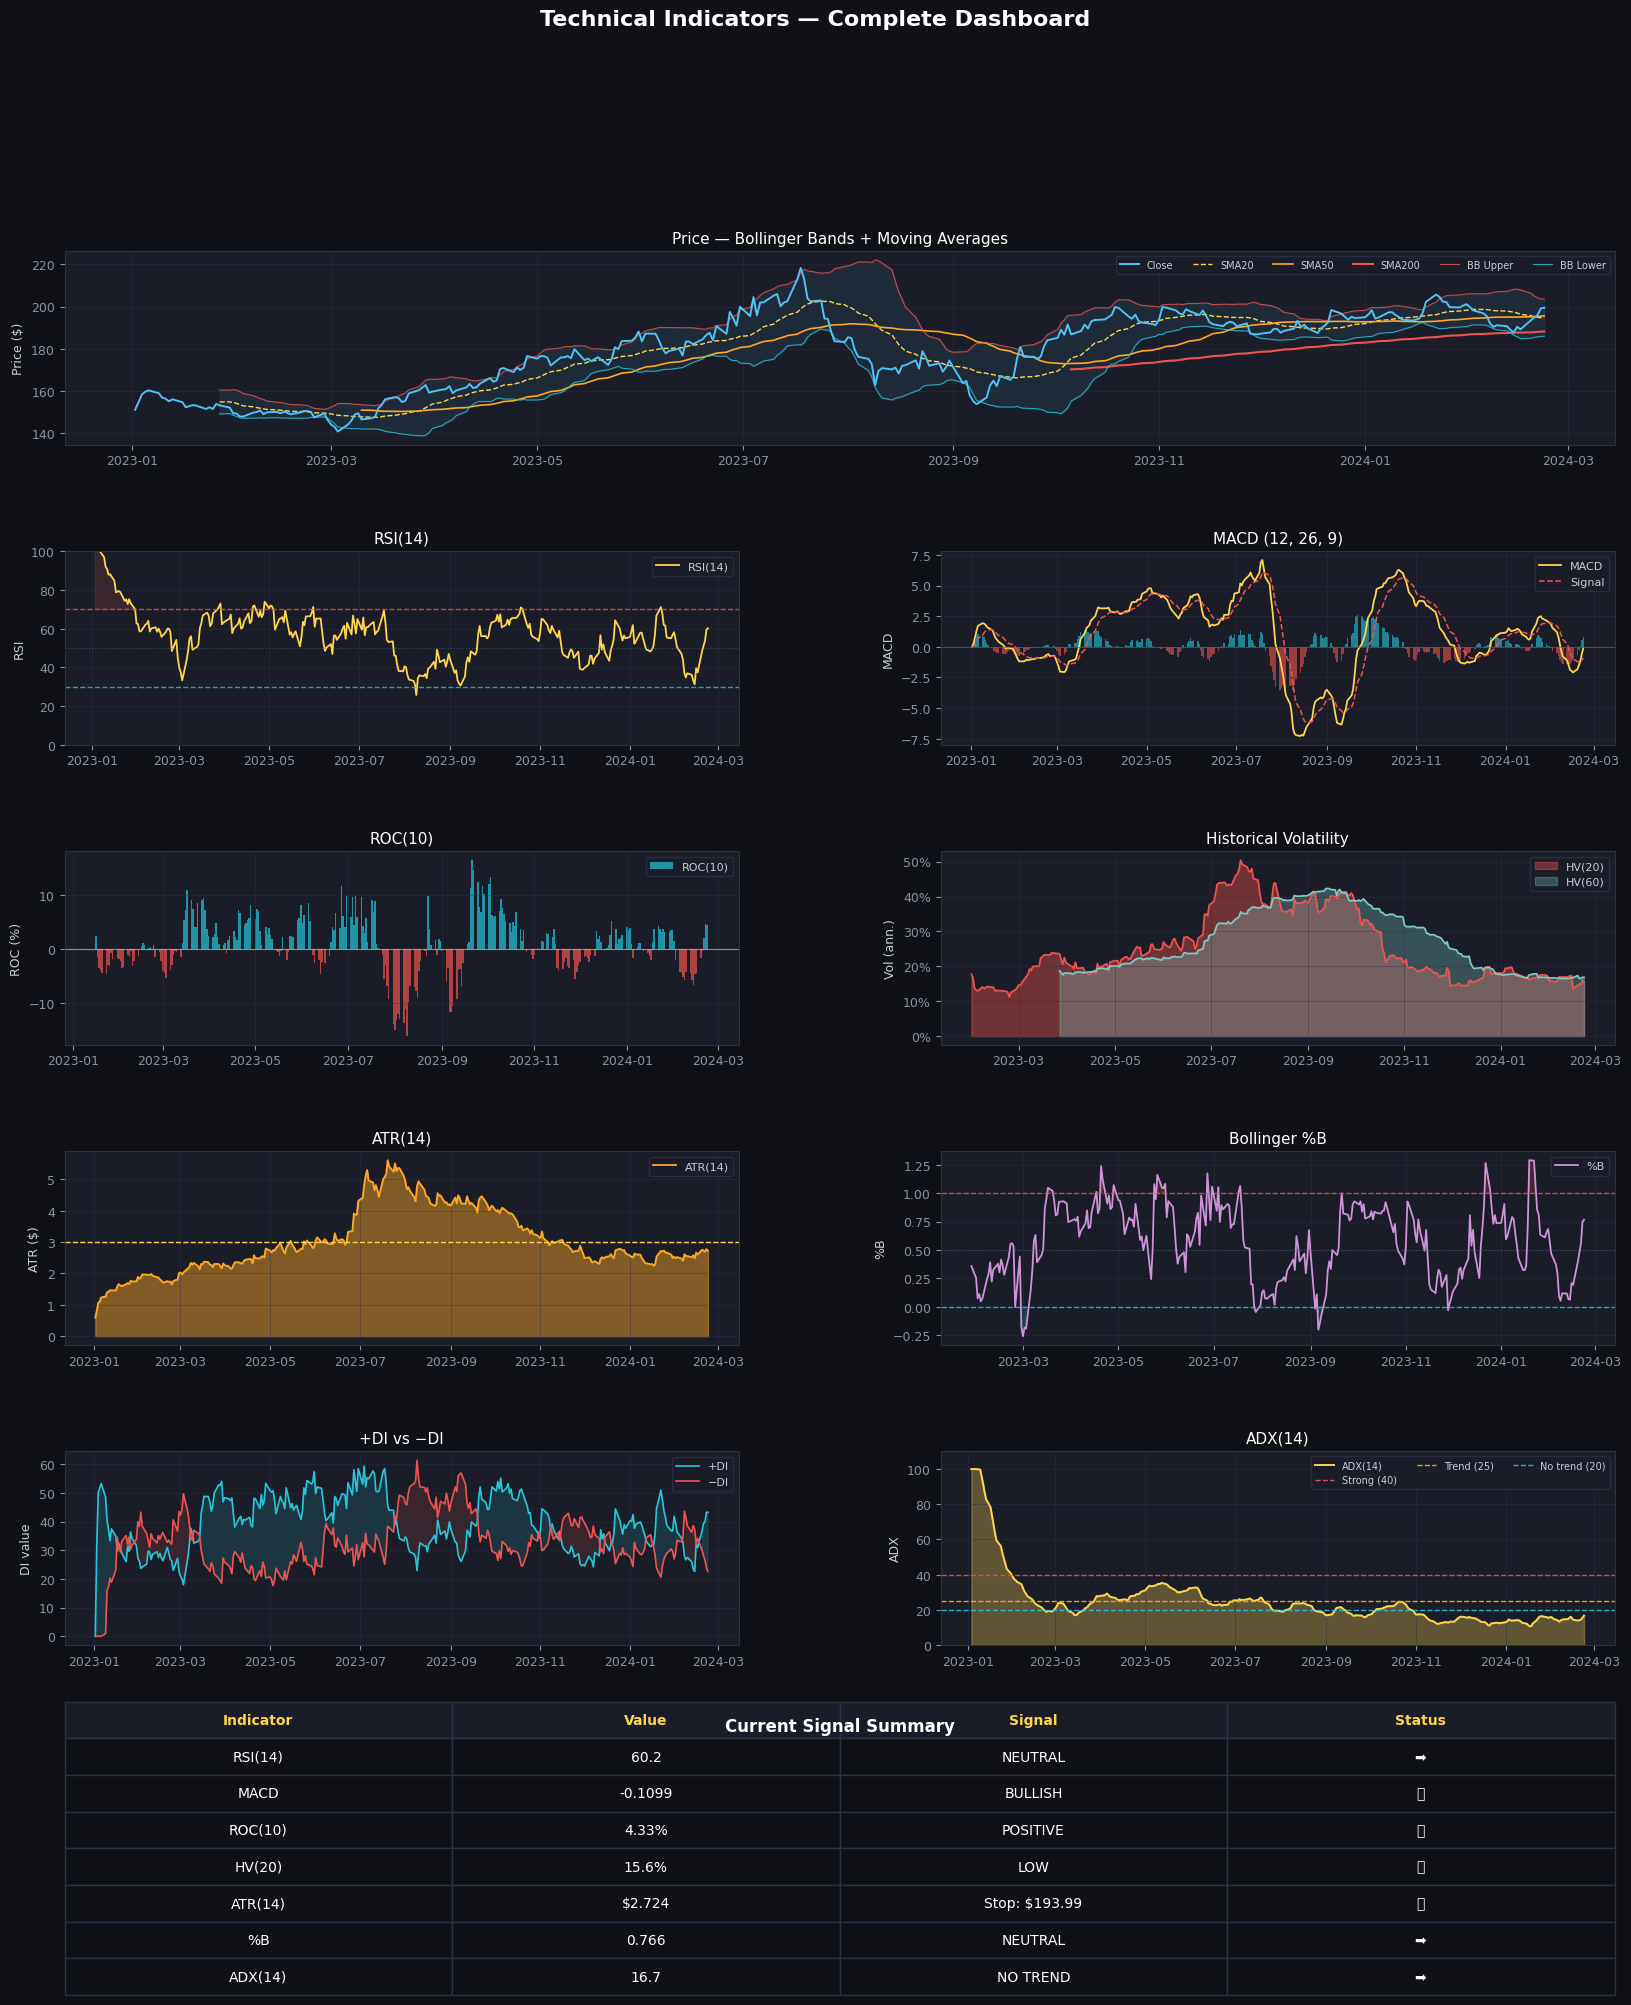

✅ Dashboard saved to outputs/indicators_dashboard.png


In [28]:
fig = plt.figure(figsize=(20, 22))
fig.suptitle('Technical Indicators — Complete Dashboard',
             fontsize=16, fontweight='bold', color='white', y=0.99)

gs = gridspec.GridSpec(6, 2, figure=fig,
                       hspace=0.55, wspace=0.3)

# ── 1. Price + BB + MAs ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(bb_upper.index, bb_upper, bb_lower,
                 alpha=0.08, color=C_PRICE)
ax1.plot(prices.index, prices,       color=C_PRICE,  lw=1.4, label='Close',    zorder=5)
ax1.plot(sma20.index,  sma20,        color=C_GOLD,   lw=1.0, ls='--', label='SMA20')
ax1.plot(mas['SMA_50'].index,  mas['SMA_50'],  color=C_ORANGE, lw=1.2, label='SMA50')
ax1.plot(mas['SMA_200'].index, mas['SMA_200'], color=C_RED,    lw=1.5, label='SMA200')
ax1.plot(bb_upper.index, bb_upper, color=C_RED,   lw=0.8, alpha=0.8, label='BB Upper')
ax1.plot(bb_lower.index, bb_lower, color=C_GREEN, lw=0.8, alpha=0.8, label='BB Lower')
ax1.set_title('Price — Bollinger Bands + Moving Averages',
              fontsize=11, color='white')
ax1.set_ylabel('Price ($)')
ax1.legend(fontsize=7, ncol=6)
ax1.grid(True, alpha=0.4)

# ── 2. RSI ───────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(rsi.index, rsi, color=C_GOLD, lw=1.3, label='RSI(14)')
ax2.axhline(70, color=C_RED,   ls='--', lw=1.0, alpha=0.8)
ax2.axhline(30, color=C_GREEN, ls='--', lw=1.0, alpha=0.8)
ax2.axhline(50, color=C_GRAY,  ls=':',  lw=0.8, alpha=0.6)
ax2.fill_between(rsi.index, rsi, 70, where=(rsi>=70), color=C_RED,   alpha=0.15)
ax2.fill_between(rsi.index, rsi, 30, where=(rsi<=30), color=C_GREEN, alpha=0.15)
ax2.set_ylim(0, 100)
ax2.set_title('RSI(14)', fontsize=11, color='white')
ax2.set_ylabel('RSI')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.4)

# ── 3. MACD ──────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(macd.index,     macd,     color=C_GOLD, lw=1.3, label='MACD')
ax3.plot(sig_line.index, sig_line, color=C_RED,  lw=1.1, ls='--', label='Signal')
colors_h = [C_GREEN if v >= 0 else C_RED for v in histogram.fillna(0)]
ax3.bar(histogram.index, histogram, color=colors_h, alpha=0.6, width=1)
ax3.axhline(0, color=C_GRAY, lw=0.8, alpha=0.6)
ax3.set_title('MACD (12, 26, 9)', fontsize=11, color='white')
ax3.set_ylabel('MACD')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.4)

# ── 4. ROC ───────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
colors_roc = [C_GREEN if v >= 0 else C_RED for v in roc.fillna(0)]
ax4.bar(roc.index, roc, color=colors_roc, alpha=0.7, width=1, label='ROC(10)')
ax4.axhline(0, color='white', lw=0.8, alpha=0.5)
ax4.set_title('ROC(10)', fontsize=11, color='white')
ax4.set_ylabel('ROC (%)')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.4)

# ── 5. Historical Volatility ─────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
ax5.fill_between(hv20.index, hv20, alpha=0.4, color=C_RED,  label='HV(20)')
ax5.fill_between(hv60.index, hv60, alpha=0.3, color=C_TEAL, label='HV(60)')
ax5.plot(hv20.index, hv20, color=C_RED,  lw=1.2)
ax5.plot(hv60.index, hv60, color=C_TEAL, lw=1.2)
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax5.set_title('Historical Volatility', fontsize=11, color='white')
ax5.set_ylabel('Vol (ann.)')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.4)

# ── 6. ATR ───────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[3, 0])
ax6.fill_between(atr.index, atr, alpha=0.45, color=C_ORANGE)
ax6.plot(atr.index, atr, color=C_ORANGE, lw=1.3, label='ATR(14)')
ax6.axhline(atr.mean(), color=C_GOLD, ls='--', lw=1.0)
ax6.set_title('ATR(14)', fontsize=11, color='white')
ax6.set_ylabel('ATR ($)')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.4)

# ── 7. %B ────────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[3, 1])
ax7.plot(pct_b.index, pct_b, color=C_PURPLE, lw=1.3, label='%B')
ax7.axhline(1.0, color=C_RED,   ls='--', lw=1.0, alpha=0.8)
ax7.axhline(0.5, color=C_GRAY,  ls=':',  lw=0.8, alpha=0.6)
ax7.axhline(0.0, color=C_GREEN, ls='--', lw=1.0, alpha=0.8)
ax7.fill_between(pct_b.index, pct_b, 1,
                 where=(pct_b > 1), color=C_RED,   alpha=0.2)
ax7.fill_between(pct_b.index, pct_b, 0,
                 where=(pct_b < 0), color=C_GREEN, alpha=0.2)
ax7.set_title('Bollinger %B', fontsize=11, color='white')
ax7.set_ylabel('%B')
ax7.legend(fontsize=8)
ax7.grid(True, alpha=0.4)

# ── 8. +DI / -DI ─────────────────────────────────────────────────
ax8 = fig.add_subplot(gs[4, 0])
ax8.plot(plus_di.index,  plus_di,  color=C_GREEN, lw=1.2, label='+DI')
ax8.plot(minus_di.index, minus_di, color=C_RED,   lw=1.2, label='−DI')
ax8.fill_between(plus_di.index, plus_di, minus_di,
                 where=(plus_di >= minus_di), color=C_GREEN, alpha=0.15)
ax8.fill_between(plus_di.index, plus_di, minus_di,
                 where=(plus_di <  minus_di), color=C_RED,   alpha=0.15)
ax8.set_title('+DI vs −DI', fontsize=11, color='white')
ax8.set_ylabel('DI value')
ax8.legend(fontsize=8)
ax8.grid(True, alpha=0.4)

# ── 9. ADX ───────────────────────────────────────────────────────
ax9 = fig.add_subplot(gs[4, 1])
ax9.fill_between(adx.index, adx, alpha=0.3, color=C_GOLD)
ax9.plot(adx.index, adx, color=C_GOLD, lw=1.4, label='ADX(14)')
ax9.axhline(40, color=C_RED,    ls='--', lw=1.0, alpha=0.9, label='Strong (40)')
ax9.axhline(25, color=C_ORANGE, ls='--', lw=1.0, alpha=0.9, label='Trend (25)')
ax9.axhline(20, color=C_GREEN,  ls='--', lw=1.0, alpha=0.9, label='No trend (20)')
ax9.set_ylim(0, max(adx.max() * 1.1, 50))
ax9.set_title('ADX(14)', fontsize=11, color='white')
ax9.set_ylabel('ADX')
ax9.legend(fontsize=7, ncol=3)
ax9.grid(True, alpha=0.4)

# ── 10. Signal Summary Table ─────────────────────────────────────
ax10 = fig.add_subplot(gs[5, :])
ax10.axis('off')

signals = [
    ['RSI(14)',      f"{rsi.iloc[-1]:.1f}",
     'OVERBOUGHT' if rsi.iloc[-1]>70 else ('OVERSOLD' if rsi.iloc[-1]<30 else 'NEUTRAL'),
     '⚠️' if rsi.iloc[-1]>70 else ('✅' if rsi.iloc[-1]<30 else '➡️')],
    ['MACD',        f"{macd.iloc[-1]:.4f}",
     'BULLISH' if macd.iloc[-1]>sig_line.iloc[-1] else 'BEARISH',
     '✅' if macd.iloc[-1]>sig_line.iloc[-1] else '⚠️'],
    ['ROC(10)',      f"{roc.iloc[-1]:.2f}%",
     'POSITIVE' if roc.iloc[-1]>0 else 'NEGATIVE',
     '✅' if roc.iloc[-1]>0 else '⚠️'],
    ['HV(20)',       f"{hv20.iloc[-1]:.1%}",
     'HIGH' if hv20.iloc[-1]>hv20.mean() else 'LOW',
     '⚠️' if hv20.iloc[-1]>hv20.mean() else '✅'],
    ['ATR(14)',      f"${atr.iloc[-1]:.3f}",
     f"Stop: ${prices.iloc[-1]-2*atr.iloc[-1]:.2f}", '📍'],
    ['%B',          f"{pct_b.iloc[-1]:.3f}",
     'OVERBOUGHT' if pct_b.iloc[-1]>1 else ('OVERSOLD' if pct_b.iloc[-1]<0 else 'NEUTRAL'),
     '⚠️' if pct_b.iloc[-1]>1 else ('✅' if pct_b.iloc[-1]<0 else '➡️')],
    ['ADX(14)',      f"{adx.iloc[-1]:.1f}",
     'STRONG TREND' if adx.iloc[-1]>40 else ('TRENDING' if adx.iloc[-1]>25 else 'NO TREND'),
     '🚀' if adx.iloc[-1]>40 else ('✅' if adx.iloc[-1]>25 else '➡️')],
]

table = ax10.table(
    cellText=signals,
    colLabels=['Indicator', 'Value', 'Signal', 'Status'],
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

for (row, col), cell in table.get_celld().items():
    cell.set_facecolor('#0F1117')
    cell.set_text_props(color='white')
    cell.set_edgecolor('#2D3147')
    if row == 0:
        cell.set_facecolor('#1A1D27')
        cell.set_text_props(color=C_GOLD, fontweight='bold')

ax10.set_title('Current Signal Summary', fontsize=12,
               color='white', fontweight='bold', pad=15)

plt.savefig('outputs/indicators_dashboard.png',
            dpi=140, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print("✅ Dashboard saved to outputs/indicators_dashboard.png")

---
## ✅ Conclusion

This notebook covered all **8 technical indicators** used in the ML trading pipeline :

| Family | Indicators | Purpose |
|--------|-----------|---------|
| **Momentum** | RSI, MACD, ROC | Measure speed and direction of price movement |
| **Volatility** | HV, ATR, Bollinger Bands | Quantify risk and position sizing |
| **Trend** | ADX, SMA, EMA | Identify direction and strength of trend |

### Key Takeaways

> - **RSI** and **Bollinger %B** identify extreme market conditions
> - **MACD** captures momentum transitions via EMA crossovers
> - **ATR** provides adaptive stop-loss levels in price units
> - **ADX** filters between trending and ranging regimes
> - **Moving Averages** define the overall market structure

### Next Step → Notebook 03

These indicators are assembled into a **16-feature panel** (`build_feature_matrix`) and fed into the ML classification model (XGBoost) in the next notebook.

---
*Notebook 02 / 05 — Technical Indicators Visualization*